# Challenge 19

<ipython-input-22-e64ed571ae8c>:6: RuntimeWarning: overflow encountered in double_scalars
  return -1000*y + 3000 - 2000*np.exp(-t)
<ipython-input-22-e64ed571ae8c>:19: RuntimeWarning: invalid value encountered in double_scalars
  y[i] = y[i-1] + h * f(t[i-1], y[i-1])


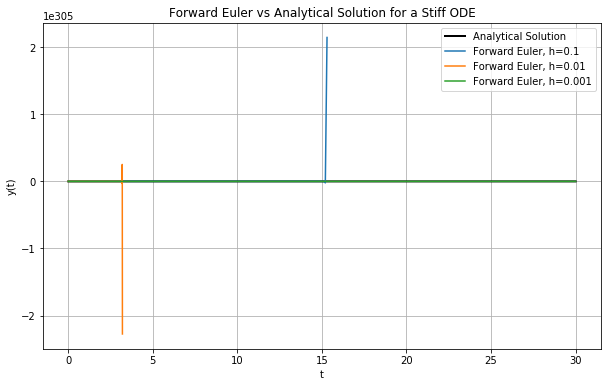

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ODE
def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

# Exact solution
def y_exact(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

# Forward Euler
def forward_euler(f, y0, t0, tf, h):
    t = np.arange(t0, tf + h, h)
    y = np.zeros_like(t)
    y[0] = y0
    
    for i in range(1, len(t)):
        y[i] = y[i-1] + h * f(t[i-1], y[i-1])
    
    return t, y

# Parameters
y0 = 0
t0 = 0
tf = 30
h_values = [0.1, 0.01, 0.001]

# Exact curve for smooth plotting
t_exact = np.linspace(t0, tf, 5000)
y_true = y_exact(t_exact)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(t_exact, y_true, 'k', linewidth=2, label='Analytical Solution')

for h in h_values:
    t_num, y_num = forward_euler(f, y0, t0, tf, h)
    plt.plot(t_num, y_num, label=f'Forward Euler, h={h}')

plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Forward Euler vs Analytical Solution for a Stiff ODE')
plt.legend()
plt.grid(True)
plt.show()

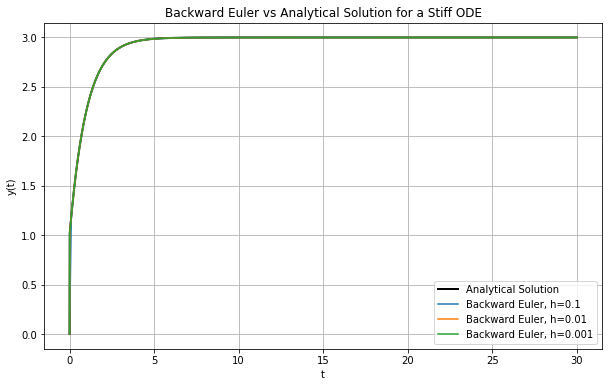

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ODE
def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

# Exact solution
def y_exact(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

# Backward Euler
def backward_euler(y0, t0, tf, h):
    t = np.arange(t0, tf + h, h)
    y = np.zeros_like(t, dtype=float)
    y[0] = y0

    for i in range(1, len(t)):
        t_next = t[i]
        y[i] = (y[i-1] + h*(3000 - 2000*np.exp(-t_next))) / (1 + 1000*h)

    return t, y

# Parameters
y0 = 0
t0 = 0
tf = 30
h_values = [0.1, 0.01, 0.001]

# Exact curve for smooth plotting
t_exact = np.linspace(t0, tf, 5000)
y_true = y_exact(t_exact)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(t_exact, y_true, 'k', linewidth=2, label='Analytical Solution')

for h in h_values:
    t_num, y_num = backward_euler(y0, t0, tf, h)
    plt.plot(t_num, y_num, label=f'Backward Euler, h={h}')

plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Backward Euler vs Analytical Solution for a Stiff ODE')
plt.legend()
plt.grid(True)
plt.show()